## Task


The aim of the assignment is to apply the NLP techniques you have learnt in class to analyse one of the 
datasets described below.   
• Note: some of the datasets are quite large, so you may need to sample a small percentage of the 
data and work that. 
The exact tasks performed may depend on the dataset chosen, but we would expect to see some of the 
following: 
#### 1. Preliminary analysis:  
Briefly describe the data:

What is the structure of the dataset? What type of task was the dataset collected for? 

What type of documents does it contain? How many are there? How long are they on average and 

what is their distribution? 

How big is the vocabulary of the collection? How big is the vocabulary of a document on average? 

Play around with documents using code from the early parts of the course. For example, you could:
Cluster the documents, visualise the clusters and to try to understand what types of groups are 
present.

Index the documents so that you can perform keyword search over them. 

Train a Word2Vec embedding and investigate the properties of the resulting embedding. 
#### 2. Training models: 
Each dataset has been created with a particular task in mind. You don’t necessarily need to tackle that 
particular problem, but you do need to train some model(s) on the data:

train ML models (e.g. a linear classifier, an LSTM and/or a Transformer) to perform a particular 

task on the data; 
if possible, try to fine-tune a pretrained models on the same task and compare their performance; 

try an LLM on the task, comparing one, few and zero-shot performance;  
and perhaps even try to fine-tune a small LLM on the task (if it makes sense to do so).   
#### 3. Possible extensions: 
Depending on the dataset chosen there will be many additional investigations that you could perform, 
for example:  
- investigate another task on the same dataset  
- investigate the same task on a related dataset 
- use text-to-speech and speech-to-text models to create a voice interactive chatbot
- create your own dialog dataset by transcribing audio conversations (e.g. using MS Teams).  

In [1]:
from datasets import load_dataset

dataset = load_dataset("neural-bridge/rag-dataset-12000")

README.md:   0%|          | 0.00/5.18k [00:00<?, ?B/s]

(…)-00000-of-00001-9df3a936e1f63191.parquet:   0%|          | 0.00/23.1M [00:00<?, ?B/s]

(…)-00000-of-00001-af2a9f454ad1b8a3.parquet:   0%|          | 0.00/5.79M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9600 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2400 [00:00<?, ? examples/s]

In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 9600
    })
    test: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 2400
    })
})

In [3]:
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

In [4]:
print('Trian dataset len:', len(train_df))
print('Test dataset len:', len(test_df))

Trian dataset len: 9600
Test dataset len: 2400


In [5]:
### showing some examples

context = train_df['context'][0]
question = train_df['question'][0]
answer = train_df['answer'][0]

In [6]:
context

'Caption: Tasmanian berry grower Nic Hansen showing Macau chef Antimo Merone around his property as part of export engagement activities.\nTHE RISE and rise of the Australian strawberry, raspberry and blackberry industries has seen the sectors redouble their international trade focus, with the release of a dedicated export plan to grow their global presence over the next 10 years.\nDriven by significant grower input, the Berry Export Summary 2028 maps the sectors’ current position, where they want to be, high-opportunity markets and next steps.\nHort Innovation trade manager Jenny Van de Meeberg said the value and volume of raspberry and blackberry exports rose by 100 per cent between 2016 and 2017. She said the Australian strawberry industry experienced similar success with an almost 30 per cent rise in export volume and a 26 per cent rise in value to $32.6M over the same period.\n“Australian berry sectors are in a firm position at the moment,” she said. “Production, adoption of prote

In [7]:
question

'What is the Berry Export Summary 2028 and what is its purpose?'

In [8]:
answer

'The Berry Export Summary 2028 is a dedicated export plan for the Australian strawberry, raspberry, and blackberry industries. It maps the sectors’ current position, where they want to be, high-opportunity markets, and next steps. The purpose of this plan is to grow their global presence over the next 10 years.'

### Data Exploration

In [9]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from textblob import TextBlob
from tqdm import tqdm

In [10]:
# Count NaN / null values per column
train_null_counts = train_df.isna().sum()

# Count NaN / null values per column
test_null_counts = test_df.isna().sum()

null_counts = train_null_counts + test_null_counts
# Print the result
print(f"NaN/null values per column: {null_counts}")
print(f"NaN/null values per column in train: {train_null_counts}")
print(f"NaN/null values per column in test: {test_null_counts}")


train_df = train_df.dropna()
test_df = test_df.dropna()

print('Any missing values: ')
print(train_df.isnull().any() & test_df.isnull().any())

NaN/null values per column: context     0
question    3
answer      3
dtype: int64
NaN/null values per column in train: context     0
question    2
answer      2
dtype: int64
NaN/null values per column in test: context     0
question    1
answer      1
dtype: int64
Any missing values: 
context     False
question    False
answer      False
dtype: bool


In [11]:
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Initialize stopwords
stop_words = set(stopwords.words('english'))

# Analyze document lengths
context_lengths = []
question_lengths = []
vocab = set()

all_tokens = []

# Function to preprocess text
def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalnum()]  # Remove punctuation
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return tokens

def append_tokens(entry):
    context_tokens = preprocess(entry['context'])
    question_tokens = preprocess(entry['question'])
    context_lengths.append(len(context_tokens))
    question_lengths.append(len(question_tokens))
    vocab.update(context_tokens)
    vocab.update(question_tokens)

    all_tokens.extend(context_tokens)
    all_tokens.extend(question_tokens)    


train_df.apply(lambda entry: append_tokens(entry), axis=1)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0       None
1       None
2       None
3       None
4       None
        ... 
9595    None
9596    None
9597    None
9598    None
9599    None
Length: 9598, dtype: object

In [12]:
fdist = FreqDist(all_tokens)
fdist

FreqDist({'one': 14432, 'also': 10326, 'new': 10136, 'time': 10131, 'like': 9989, 'would': 8828, 'get': 8782, 'said': 7855, 'people': 7767, 'first': 6947, ...})

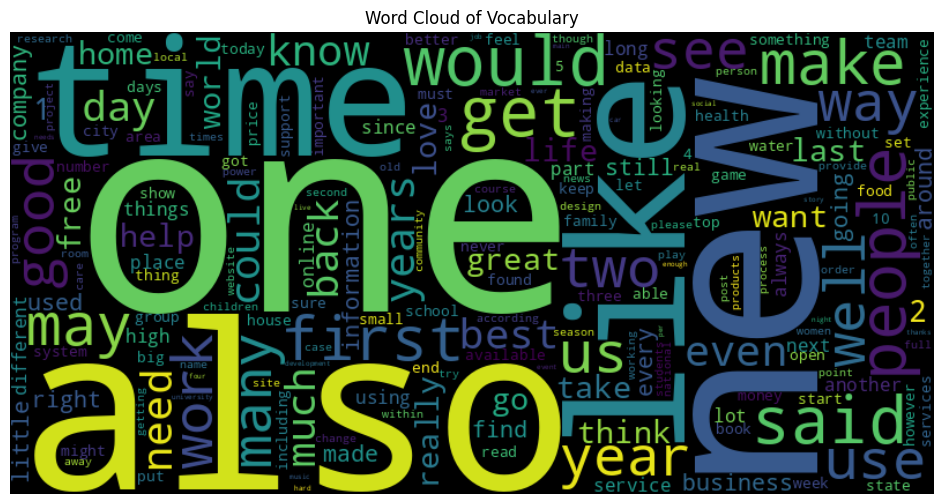

In [13]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(fdist)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Vocabulary")
plt.show()

<Axes: title={'center': 'Top 30 Most Frequent Words'}, xlabel='Samples', ylabel='Counts'>

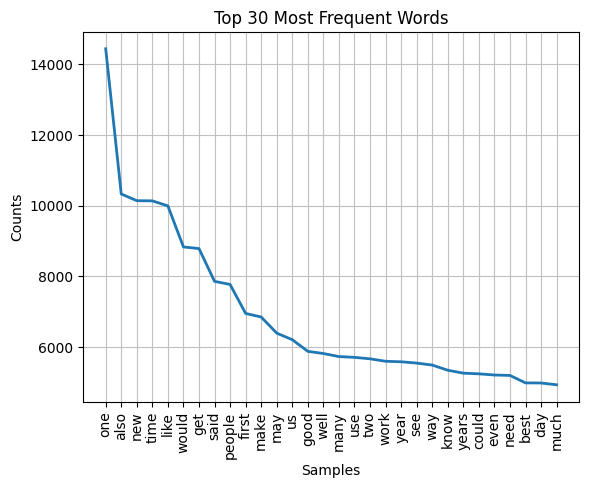

In [14]:
fdist.plot(30,  title="Top 30 Most Frequent Words")

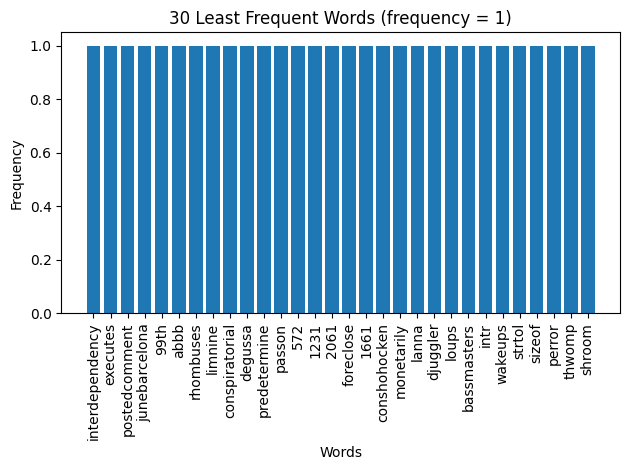

In [15]:
import pandas as pd
import seaborn as sns

least_freq = fdist.most_common()[-30:]
least_freq = pd.DataFrame(least_freq, columns=['word', 'count'])
plt.bar(least_freq['word'], least_freq['count'])
plt.xticks(rotation=90)
plt.title("30 Least Frequent Words (frequency = 1)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Number of documents: 9598
Average context length: 321.12 tokens
Average question length: 6.81 tokens
Vocabulary size: 128313


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


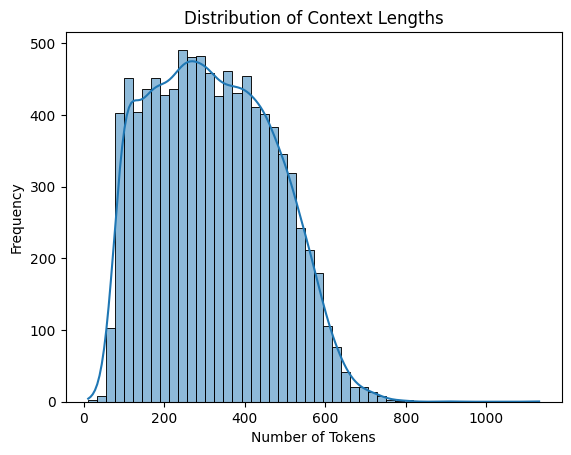

In [16]:
# Print statistics
print(f"Number of documents: {len(train_df)}")
print(f"Average context length: {sum(context_lengths)/len(context_lengths):.2f} tokens")
print(f"Average question length: {sum(question_lengths)/len(question_lengths):.2f} tokens")
print(f"Vocabulary size: {len(vocab)}")

# Plot distribution of context lengths
sns.histplot(context_lengths, bins=50, kde=True)
plt.title('Distribution of Context Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


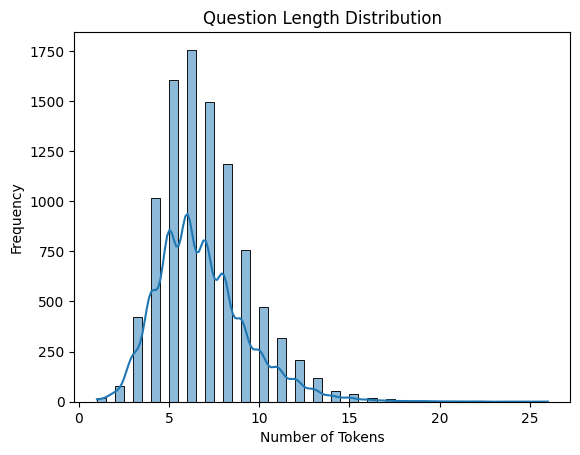

In [17]:
sns.histplot(question_lengths, bins=50, kde=True)
plt.title("Question Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

### Data cleaning

* We must drop least frequent words
* Stemming? necessary or not

### Create embeddings with Word2Vec & Faiss

Faiss is a library for efficient similarity search and clustering of dense vectors. It contains algorithms that search in sets of vectors of any size, up to ones that possibly do not fit in RAM. It also contains supporting code for evaluation and parameter tuning. Faiss is written in C++ with complete wrappers for Python/numpy. Some of the most useful algorithms are implemented on the GPU. It is developed primarily at Meta's Fundamental AI Research group.

### Clustering